In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
roc_curve,
auc)

In [13]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", np.unique(y))





Dataset Shape: (569, 30)
Classes: [0 1]


In [54]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)


In [55]:
scaler = StandardScaler()
X_train =scaler.fit_transform(X_train)
X_test =scaler.transform(X_test)

In [56]:
mle_model=LogisticRegression(penalty=None,max_iter=5000,random_state=42)
mle_model.fit(X_train,y_train)
y_pred_mle =mle_model.predict(X_test)

In [57]:
map_l2 = LogisticRegression(penalty='l2',C=1.0,solver='lbfgs',max_iter=5000,random_state=42)
map_l2.fit(X_train,y_train)
y_pred_l2=map_l2.predict(X_test)

In [58]:
map_l1 = LogisticRegression(penalty='l1',C=1.0,solver='liblinear',max_iter=5000,random_state=42)
map_l1.fit(X_train,y_train)
y_pred_l1=map_l1.predict(X_test)

In [59]:
def evaluate(model_name,y_true,y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)
    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("precision:",precision_score(y_true,y_pred))
    print("Recall:",recall_score(y_true,y_pred))
    print("f1 score:",f1_score(y_true,y_pred))
    print("\nConfusion matrix")
    print(confusion_matrix(y_true,y_pred))

In [60]:
evaluate("MLE",y_test,y_pred_mle)
evaluate("MAP(L2)",y_test,y_pred_l2)
evaluate("MAP(L2)",y_test,y_pred_l1)


MLE
Accuracy : 0.9210526315789473
precision: 0.9701492537313433
Recall: 0.9027777777777778
f1 score: 0.935251798561151

Confusion matrix
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy : 0.9824561403508771
precision: 0.9861111111111112
Recall: 0.9861111111111112
f1 score: 0.9861111111111112

Confusion matrix
[[41  1]
 [ 1 71]]

MAP(L2)
Accuracy : 0.9912280701754386
precision: 0.9863013698630136
Recall: 1.0
f1 score: 0.993103448275862

Confusion matrix
[[41  1]
 [ 0 72]]


In [61]:
print("number of coefficient")
print("MLE:",np.sum(mle_model.coef_[0]==0))
print("MAP(L2)",np.sum(map_l2.coef_[0]==0))
print("MAP(L1)",np.sum(map_l1.coef_[0]==0))


number of coefficient
MLE: 0
MAP(L2) 0
MAP(L1) 14


In [62]:
results=pd.DataFrame(columns=["Model","Accuracy","Precision","F1_score","Recall"])
result=pd.DataFrame(columns=["Model","Accuracy","Precision","Recall","F1 Sore"])
models = [
("MLE", mle_model, y_pred_mle),
("MAP L2", map_l2, y_pred_l2),
("MAP L1", map_l1, y_pred_l1)]

for name, model, pred in models:
    results.loc[len(results)]=[name,accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred)]
print(results)

    Model  Accuracy  Precision  F1_score    Recall
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


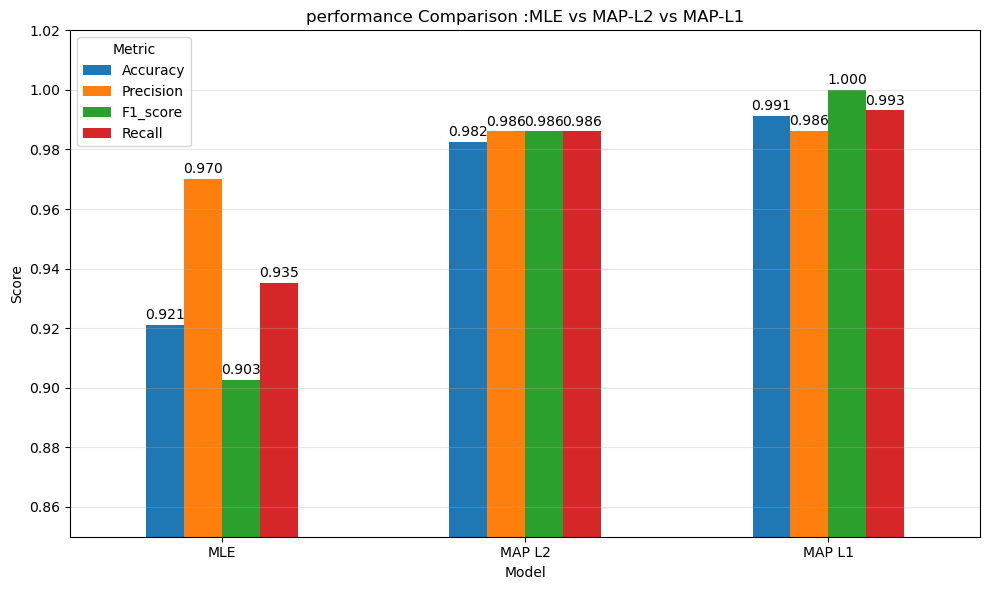

In [63]:
ax = results.set_index("Model").plot(kind="bar",figsize=(10, 6))
plt.title("performance Comparison :MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
#shows values on bars
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()

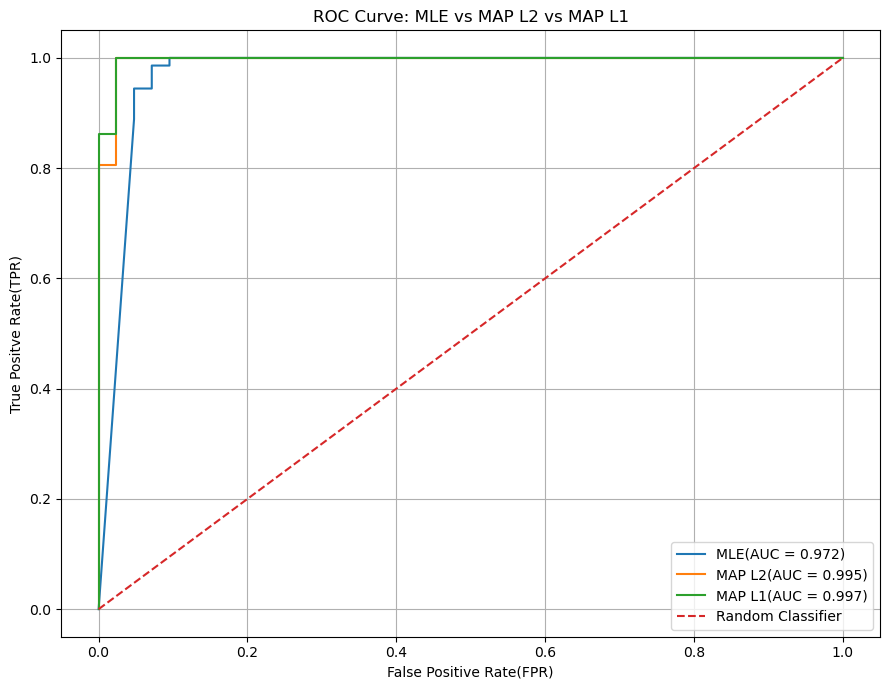

In [64]:
plt.figure(figsize=(9, 7))
for name,model,pred in models:
    # predicted probabilty for positive class
    y_prob=model.predict_proba(X_test)[:,1]
    #calculated ROC values
    fpr,tpr,thresholds=roc_curve(y_test,y_prob)
    #calculate AUC
    roc_auc=auc(fpr,tpr)
    #plot ROC curve
    plt.plot(fpr,tpr,label=f"{name}(AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate(FPR)")
plt.ylabel("True Positve Rate(TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()